# Lending Club Credit Default — Exploratory Data Analysis & PCA

**45-952 End-to-End Business Analytics — Credit Default Case**

This notebook performs exploratory data analysis (EDA) and Principal Component
Analysis (PCA) on the Lending Club loans dataset (`loanskpi.csv`), following the
same workflow style used in the course's `Untitled0` (Carseats EDA) and
`Proteins` (PCA) notebooks.

Data source: `data/loanskpi.csv` in this repository, described in
`docs/LoansDataDescr.pdf`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the data

In [2]:
data_path = "../data/loanskpi.csv"
df = pd.read_csv(data_path)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())


Shape: 9578 rows x 17 columns


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,default,tot.payment,principal,interest
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,29847.60,20892.796502,8954.803498
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,8215.92,5958.231659,2257.688341
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,13206.96,8790.257126,4416.702874
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,5844.24,4319.141090,1525.098910
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,3705.12,2415.522565,1289.597435


## 2. Dataset info, descriptive statistics, and missing values

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  default            9578 non-null   int64  
 14  tot.payment        9578 non-null   float64
 15  principal          9578 non-null   float64
 16  interest           9578 non-null   

In [4]:
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,NaN,NaN,NaN,0.80497,0.396245,0.0,1.0,1.0,1.0,1.0
purpose,9578,7,debt_consolidation,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int.rate,9578.0,NaN,NaN,NaN,0.12264,0.026847,0.06,0.1039,0.1221,0.1407,0.2164
installment,9578.0,NaN,NaN,NaN,319.089413,207.071301,15.67,163.77,268.95,432.7625,940.14
log.annual.inc,9578.0,NaN,NaN,NaN,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,14.528354
dti,9578.0,NaN,NaN,NaN,12.606679,6.88397,0.0,7.2125,12.665,17.95,29.96
fico,9578.0,NaN,NaN,NaN,710.846314,37.970537,612.0,682.0,707.0,737.0,827.0
days.with.cr.line,9578.0,NaN,NaN,NaN,4560.767197,2496.930377,178.958333,2820.0,4139.958333,5730.0,17639.95833
revol.bal,9578.0,NaN,NaN,NaN,16913.963876,33756.189557,0.0,3187.0,8596.0,18249.5,1207359.0
revol.util,9578.0,NaN,NaN,NaN,46.799236,29.014417,0.0,22.6,46.3,70.9,119.0


In [5]:
missing = pd.DataFrame(df.isnull().sum(), columns=['Missing Values'])
missing['% Missing'] = (missing['Missing Values'] / len(df) * 100).round(2)
display(missing)


,Missing Values,% Missing
credit.policy,0,0.0
purpose,0,0.0
int.rate,0,0.0
installment,0,0.0
log.annual.inc,0,0.0
dti,0,0.0
fico,0,0.0
days.with.cr.line,0,0.0
revol.bal,0,0.0
revol.util,0,0.0


## 3. Categorical variable distributions

`purpose` is the only text-categorical field; `credit.policy` and `default` are
binary flags that behave like categories.


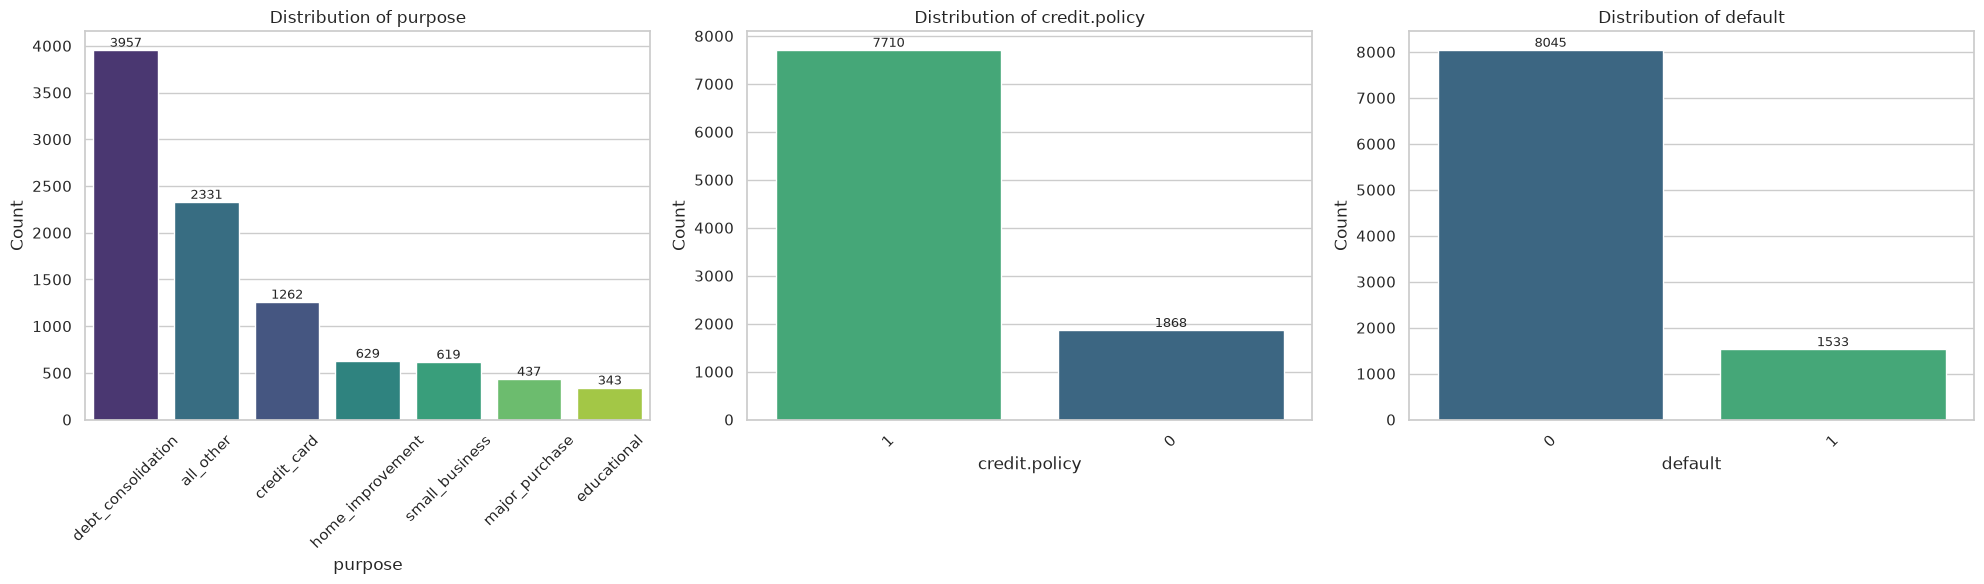

In [6]:
categorical_cols = ['purpose', 'credit.policy', 'default']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, hue=col, palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../output/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
for col in categorical_cols:
    print(f"--- {col} ---")
    display((df[col].value_counts(normalize=True) * 100).round(2).rename('% of loans'))
    print()


--- purpose ---


purpose
debt_consolidation    41.31
all_other             24.34
credit_card           13.18
home_improvement       6.57
small_business         6.46
major_purchase         4.56
educational            3.58
Name: % of loans, dtype: float64


--- credit.policy ---


credit.policy
1    80.5
0    19.5
Name: % of loans, dtype: float64


--- default ---


default
0    83.99
1    16.01
Name: % of loans, dtype: float64

## 4. Numerical variable distributions

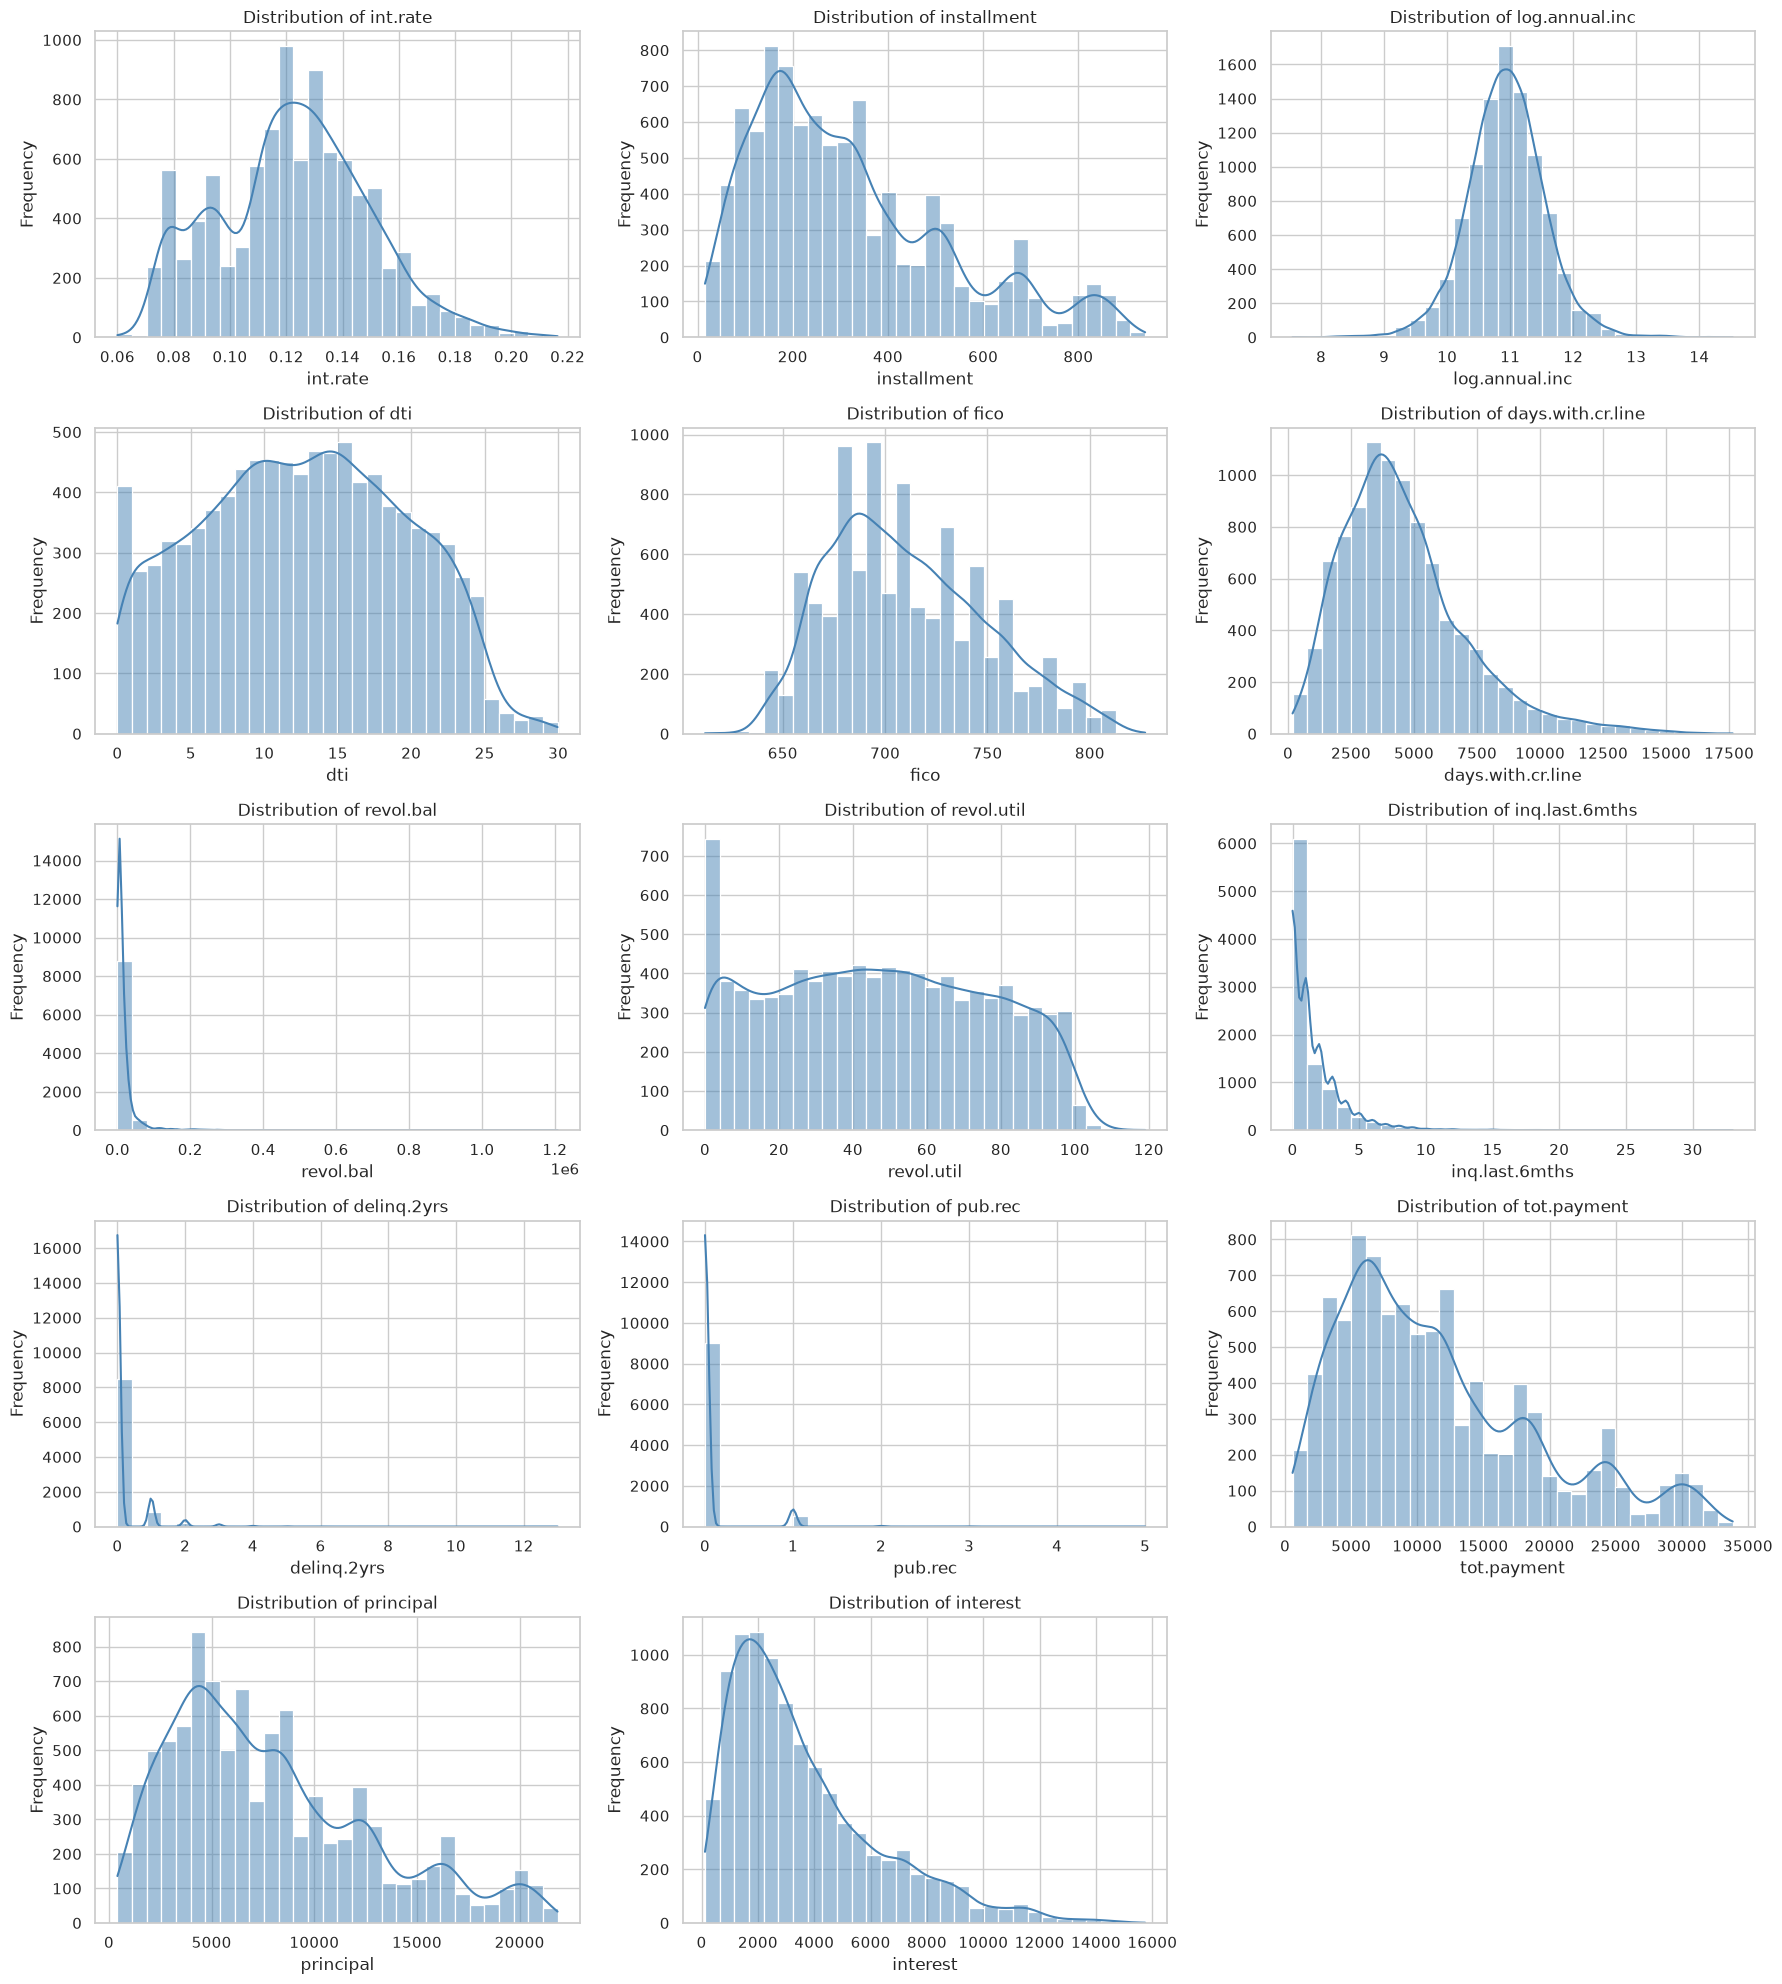

In [8]:
numeric_cols = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
                'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths',
                'delinq.2yrs', 'pub.rec', 'tot.payment', 'principal', 'interest']

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, color='steelblue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../output/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Correlation matrices and heatmaps

Two views are shown:
1. **Full correlation matrix** — all numeric fields, including the computed KPI
   fields (`tot.payment`, `principal`, `interest`) and the `default` target.
   Note that `int.rate` is expected to correlate with risk indicators such as
   `fico` and `revol.util` (per the data description), and the KPI fields are
   deterministic functions of `installment`/`int.rate`, so they will show very
   strong correlations by construction.
2. **Predictor-only correlation matrix** — restricted to the borrower/loan
   fields known *at the time of the funding decision* (excludes the
   post-outcome KPI fields, which is also the feature set used for PCA below).


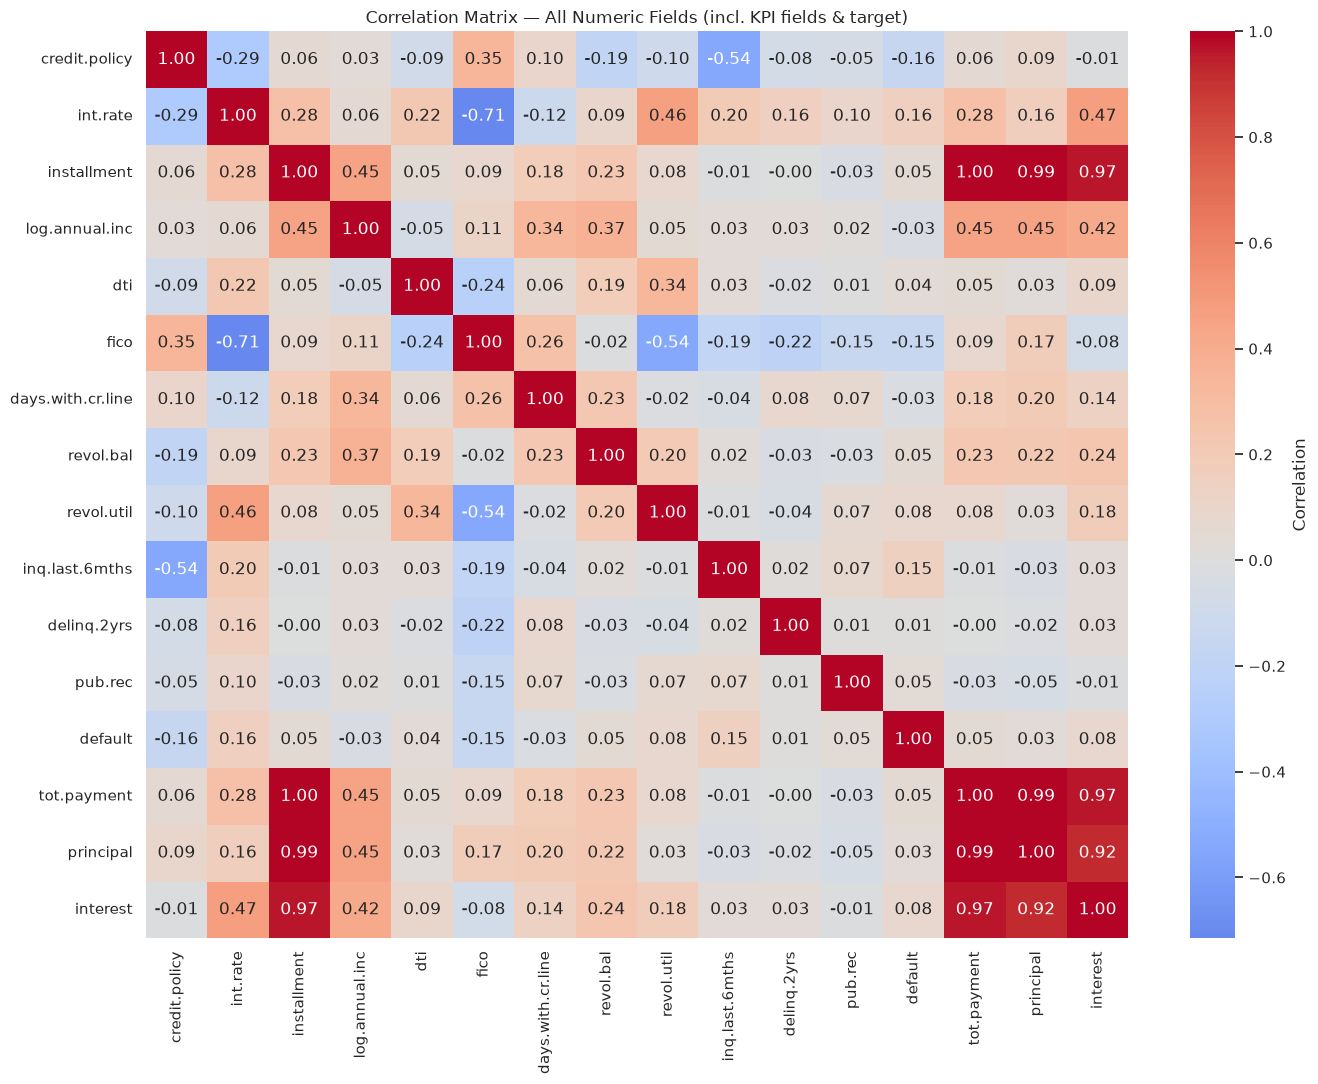

In [9]:
full_numeric = df.select_dtypes(include=[np.number])
corr_full = full_numeric.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_full, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — All Numeric Fields (incl. KPI fields & target)')
plt.tight_layout()
plt.savefig('../output/correlation_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()


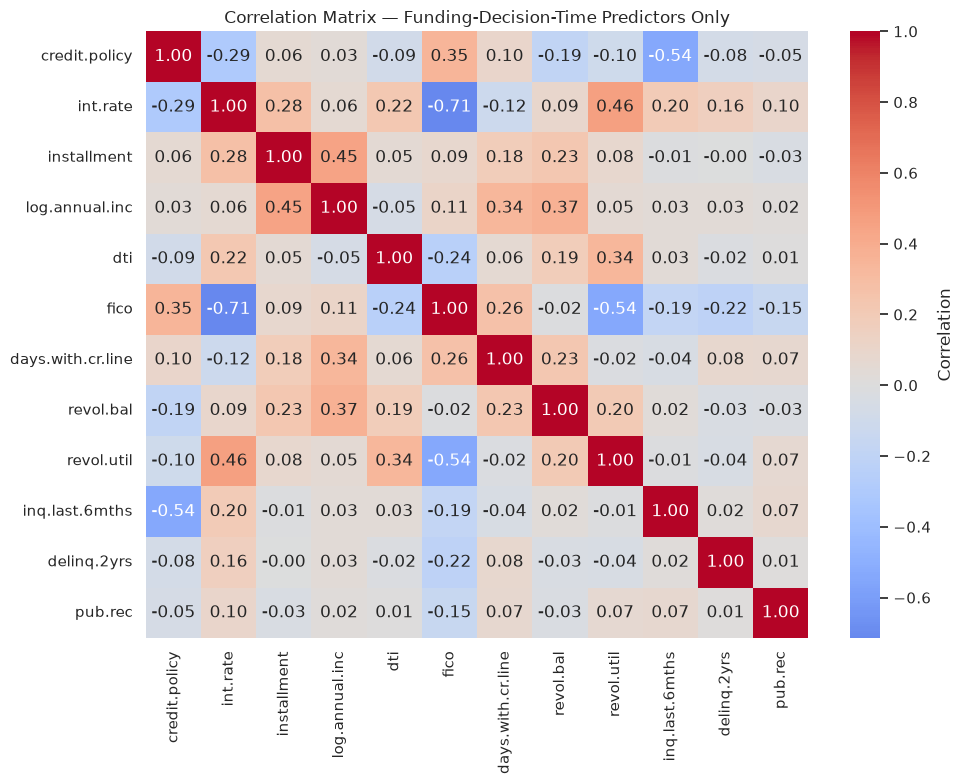

In [10]:
predictor_cols = ['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti',
                   'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
                   'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

corr_predictors = df[predictor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_predictors, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — Funding-Decision-Time Predictors Only')
plt.tight_layout()
plt.savefig('../output/correlation_matrix_predictors.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Principal Component Analysis (PCA)

PCA is run on the funding-decision-time predictors (numeric fields available
when the loan is funded, plus one-hot-encoded `purpose`). The computed KPI
fields (`tot.payment`, `principal`, `interest`) and the `default` target are
excluded from the PCA feature set to avoid leakage, since those fields are
either deterministic transforms of `installment`/`int.rate` or the outcome
itself.


In [11]:
pca_features = predictor_cols.copy()
X = pd.get_dummies(df[pca_features + ['purpose']].drop(columns=['credit.policy']).assign(**{'credit.policy': df['credit.policy']}),
                    columns=['purpose'], drop_first=True)

# Reorder for clarity: keep credit.policy as-is (already 0/1)
X = X.astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

print('Explained variance ratio per component:')
for i, ratio in enumerate(explained_variance_ratio):
    print(f'PC{i+1}: {ratio*100:.2f}%')

print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_explained_variance):
    print(f'PC{i+1}: {cum*100:.2f}%')

X_pca = pca.transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df['default'] = df['default'].values
display(pca_df.head())


Explained variance ratio per component:
PC1: 15.32%
PC2: 11.52%
PC3: 8.94%
PC4: 7.29%
PC5: 6.52%
PC6: 6.20%
PC7: 5.80%
PC8: 5.70%
PC9: 5.54%
PC10: 5.34%
PC11: 4.80%
PC12: 4.06%
PC13: 3.47%
PC14: 2.69%
PC15: 2.18%
PC16: 2.01%
PC17: 1.66%
PC18: 0.95%

Cumulative explained variance:
PC1: 15.32%
PC2: 26.83%
PC3: 35.78%
PC4: 43.07%
PC5: 49.59%
PC6: 55.79%
PC7: 61.58%
PC8: 67.28%
PC9: 72.83%
PC10: 78.17%
PC11: 82.97%
PC12: 87.04%
PC13: 90.51%
PC14: 93.19%
PC15: 95.37%
PC16: 97.38%
PC17: 99.05%
PC18: 100.00%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,default
0,-0.153119,2.161846,-1.682934,-0.792218,-0.299740,-0.476571,0.106498,0.138039,-0.170710,0.074374,-0.533295,-1.066027,-0.768604,-0.380029,0.098798,-0.512016,-0.198654,-0.242232,0
1,0.080075,0.167831,-0.473069,2.907152,0.568846,-0.175311,-0.119369,-0.603808,-0.305787,-0.503523,-0.541167,0.528335,-0.176132,0.389646,0.354878,-0.305145,0.371472,-0.053498,0
2,-0.225922,-0.653155,-1.103501,-0.935059,0.010484,-0.032410,-0.060020,-0.025105,-0.013671,-0.327530,-0.147295,-0.306741,0.073509,-0.739075,-0.292862,0.965780,0.339361,-0.422106,0
3,0.124700,-0.027540,-1.164359,-0.334469,-0.479078,-0.308380,0.031350,-0.243312,-0.127100,-0.018981,-0.425147,1.554016,0.307778,1.015428,0.405672,-0.267296,0.410083,-0.008335,0
4,-0.546866,-0.351705,0.116370,2.349499,1.454897,1.484990,-0.053194,0.395952,-0.775795,-1.172924,-0.174041,0.015567,-0.150686,0.609263,-0.801406,0.656791,0.652352,0.141182,0


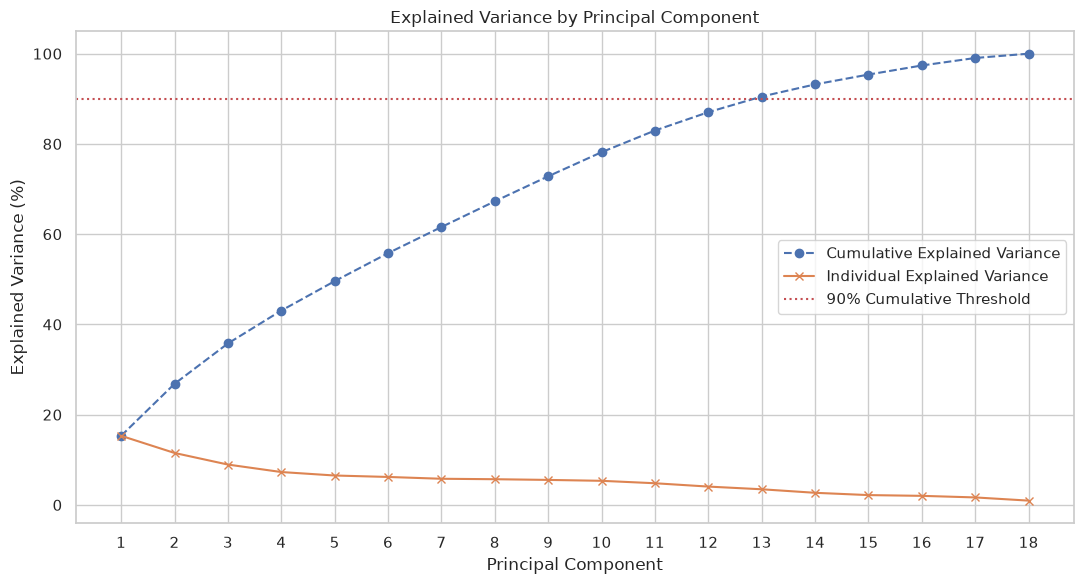

In [12]:
num_components = range(1, len(cumulative_explained_variance) + 1)

plt.figure(figsize=(11, 6))
plt.plot(num_components, cumulative_explained_variance * 100, marker='o', linestyle='--',
         label='Cumulative Explained Variance')
plt.plot(num_components, explained_variance_ratio * 100, marker='x', linestyle='-',
         label='Individual Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance by Principal Component')
plt.grid(True)
plt.xticks(num_components)
plt.axhline(y=90, color='r', linestyle=':', label='90% Cumulative Threshold')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('../output/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()


### Biplot of the first two Principal Components

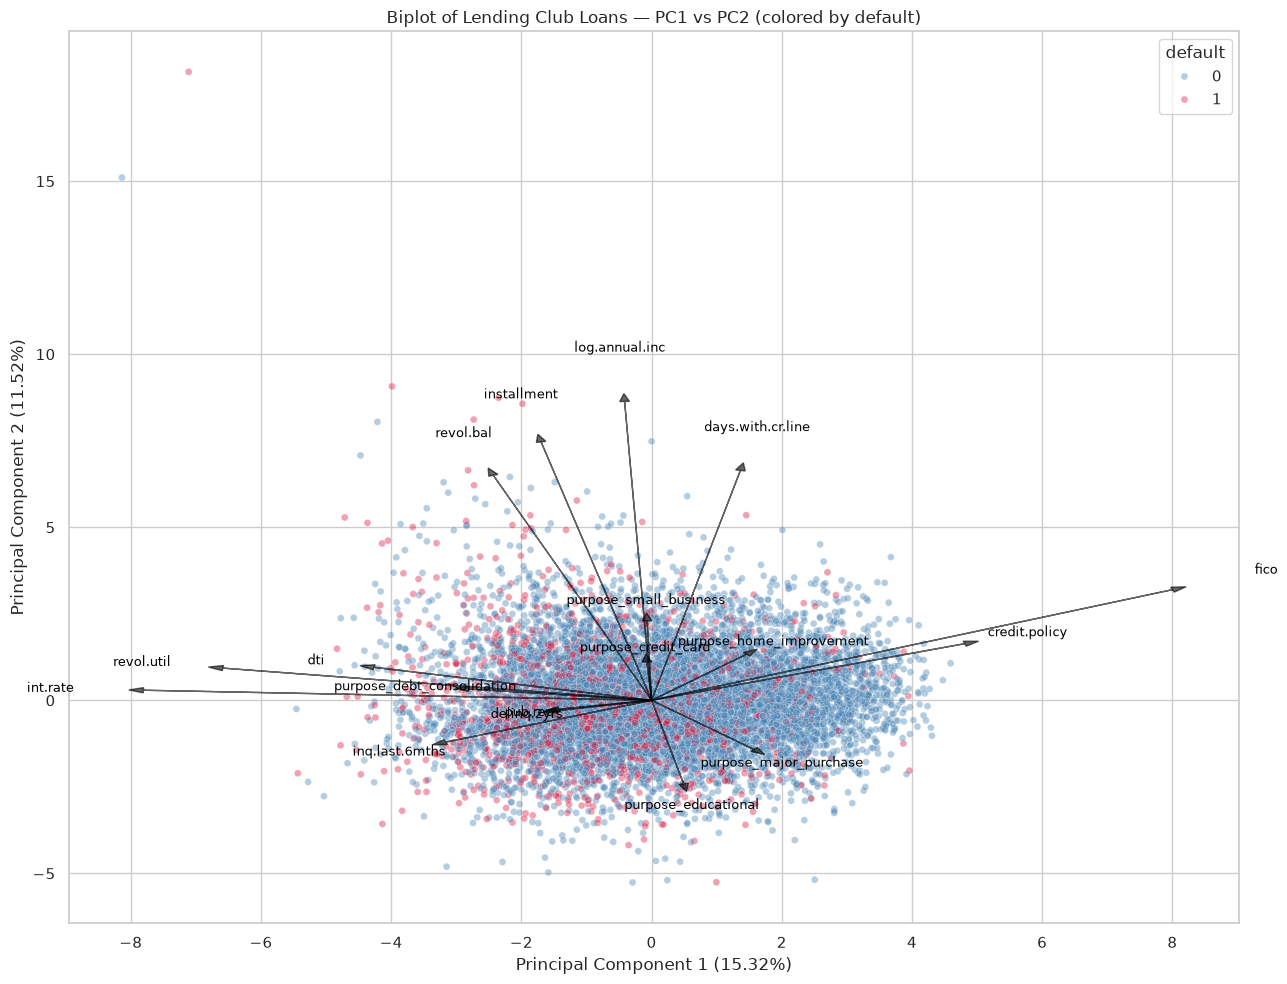

In [13]:
loadings = pca.components_
feature_names = X.columns

fig = plt.figure(figsize=(13, 10))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=pca_df['default'],
                 palette={0: 'steelblue', 1: 'crimson'}, alpha=0.4, s=25)

scale = np.abs(pca_df[['PC1', 'PC2']]).max().max() * 0.9
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[0, i] * scale, loadings[1, i] * scale,
              color='black', alpha=0.6, head_width=0.15, length_includes_head=True)
    plt.text(loadings[0, i] * scale * 1.15, loadings[1, i] * scale * 1.15, feature,
              color='black', ha='center', va='center', fontsize=9)

plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}%)')
plt.title('Biplot of Lending Club Loans — PC1 vs PC2 (colored by default)')
plt.legend(title='default', loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig('../output/pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()


### PCA Loadings Heatmap

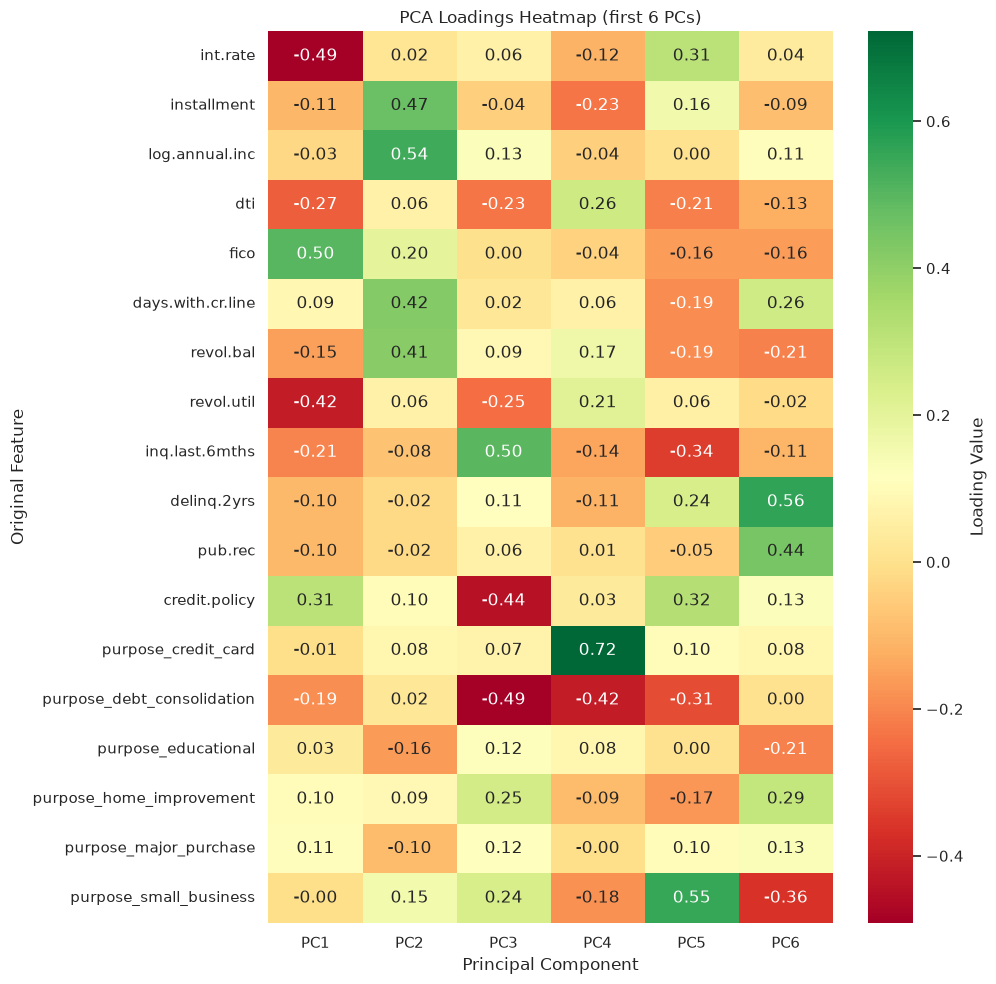

In [14]:
loadings_df = pd.DataFrame(pca.components_, columns=feature_names,
                            index=[f'PC{i+1}' for i in range(pca.n_components_)])

n_show = min(6, loadings_df.shape[0])
plt.figure(figsize=(10, 10))
sns.heatmap(loadings_df.iloc[:n_show].T, annot=True, cmap='RdYlGn', fmt=".2f",
            cbar_kws={'label': 'Loading Value'})
plt.title(f'PCA Loadings Heatmap (first {n_show} PCs)')
plt.xlabel('Principal Component')
plt.ylabel('Original Feature')
plt.tight_layout()
plt.savefig('../output/pca_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Default rate by first two principal components

A quick check of how the target variable (`default`) varies across the PCA
space, and the top absolute loadings for PC1 and PC2 for interpretation.


In [15]:
for pc in ['PC1', 'PC2', 'PC3']:
    top_loadings = loadings_df.loc[pc].abs().sort_values(ascending=False).head(5)
    print(f"Top |loadings| for {pc}:")
    for feat in top_loadings.index:
        print(f"  {feat}: {loadings_df.loc[pc, feat]:.3f}")
    print()

print('Default rate by PC1 quartile:')
pca_df['PC1_quartile'] = pd.qcut(pca_df['PC1'], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
display(pca_df.groupby('PC1_quartile', observed=True)['default'].mean().mul(100).round(2).rename('Default rate (%)'))


Top |loadings| for PC1:
  fico: 0.502
  int.rate: -0.491
  revol.util: -0.417
  credit.policy: 0.307
  dti: -0.274

Top |loadings| for PC2:
  log.annual.inc: 0.542
  installment: 0.470
  days.with.cr.line: 0.420
  revol.bal: 0.411
  fico: 0.201

Top |loadings| for PC3:
  inq.last.6mths: 0.496
  purpose_debt_consolidation: -0.491
  credit.policy: -0.445
  purpose_home_improvement: 0.249
  revol.util: -0.246

Default rate by PC1 quartile:


PC1_quartile
Q1 (low)     24.34
Q2           17.79
Q3           13.95
Q4 (high)     7.93
Name: Default rate (%), dtype: float64

## 9. Distributions split by default status (counts)

The same categorical and numerical distributions as Sections 3–4, now split
by `default` (0 = paid in full, 1 = defaulted/charged off) to see how the
shape of each variable differs between healthy and delinquent loans.


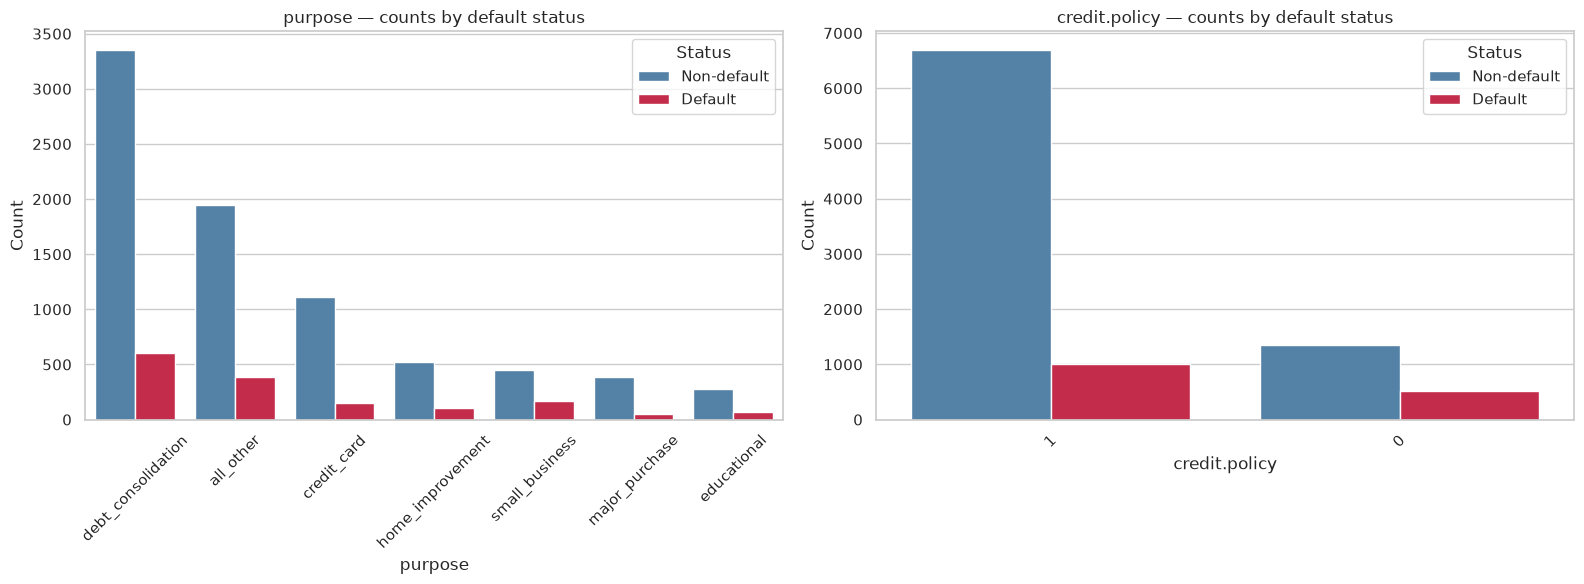

In [16]:
split_categorical_cols = ['purpose', 'credit.policy']
default_palette = {0: 'steelblue', 1: 'crimson'}
default_labels = {0: 'Non-default', 1: 'Default'}

fig, axes = plt.subplots(1, len(split_categorical_cols), figsize=(16, 6))
for ax, col in zip(axes, split_categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue='default', order=order,
                  palette=default_palette, ax=ax)
    ax.set_title(f'{col} — counts by default status')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, [default_labels[0], default_labels[1]], title='Status')
plt.tight_layout()
plt.savefig('../output/categorical_distributions_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


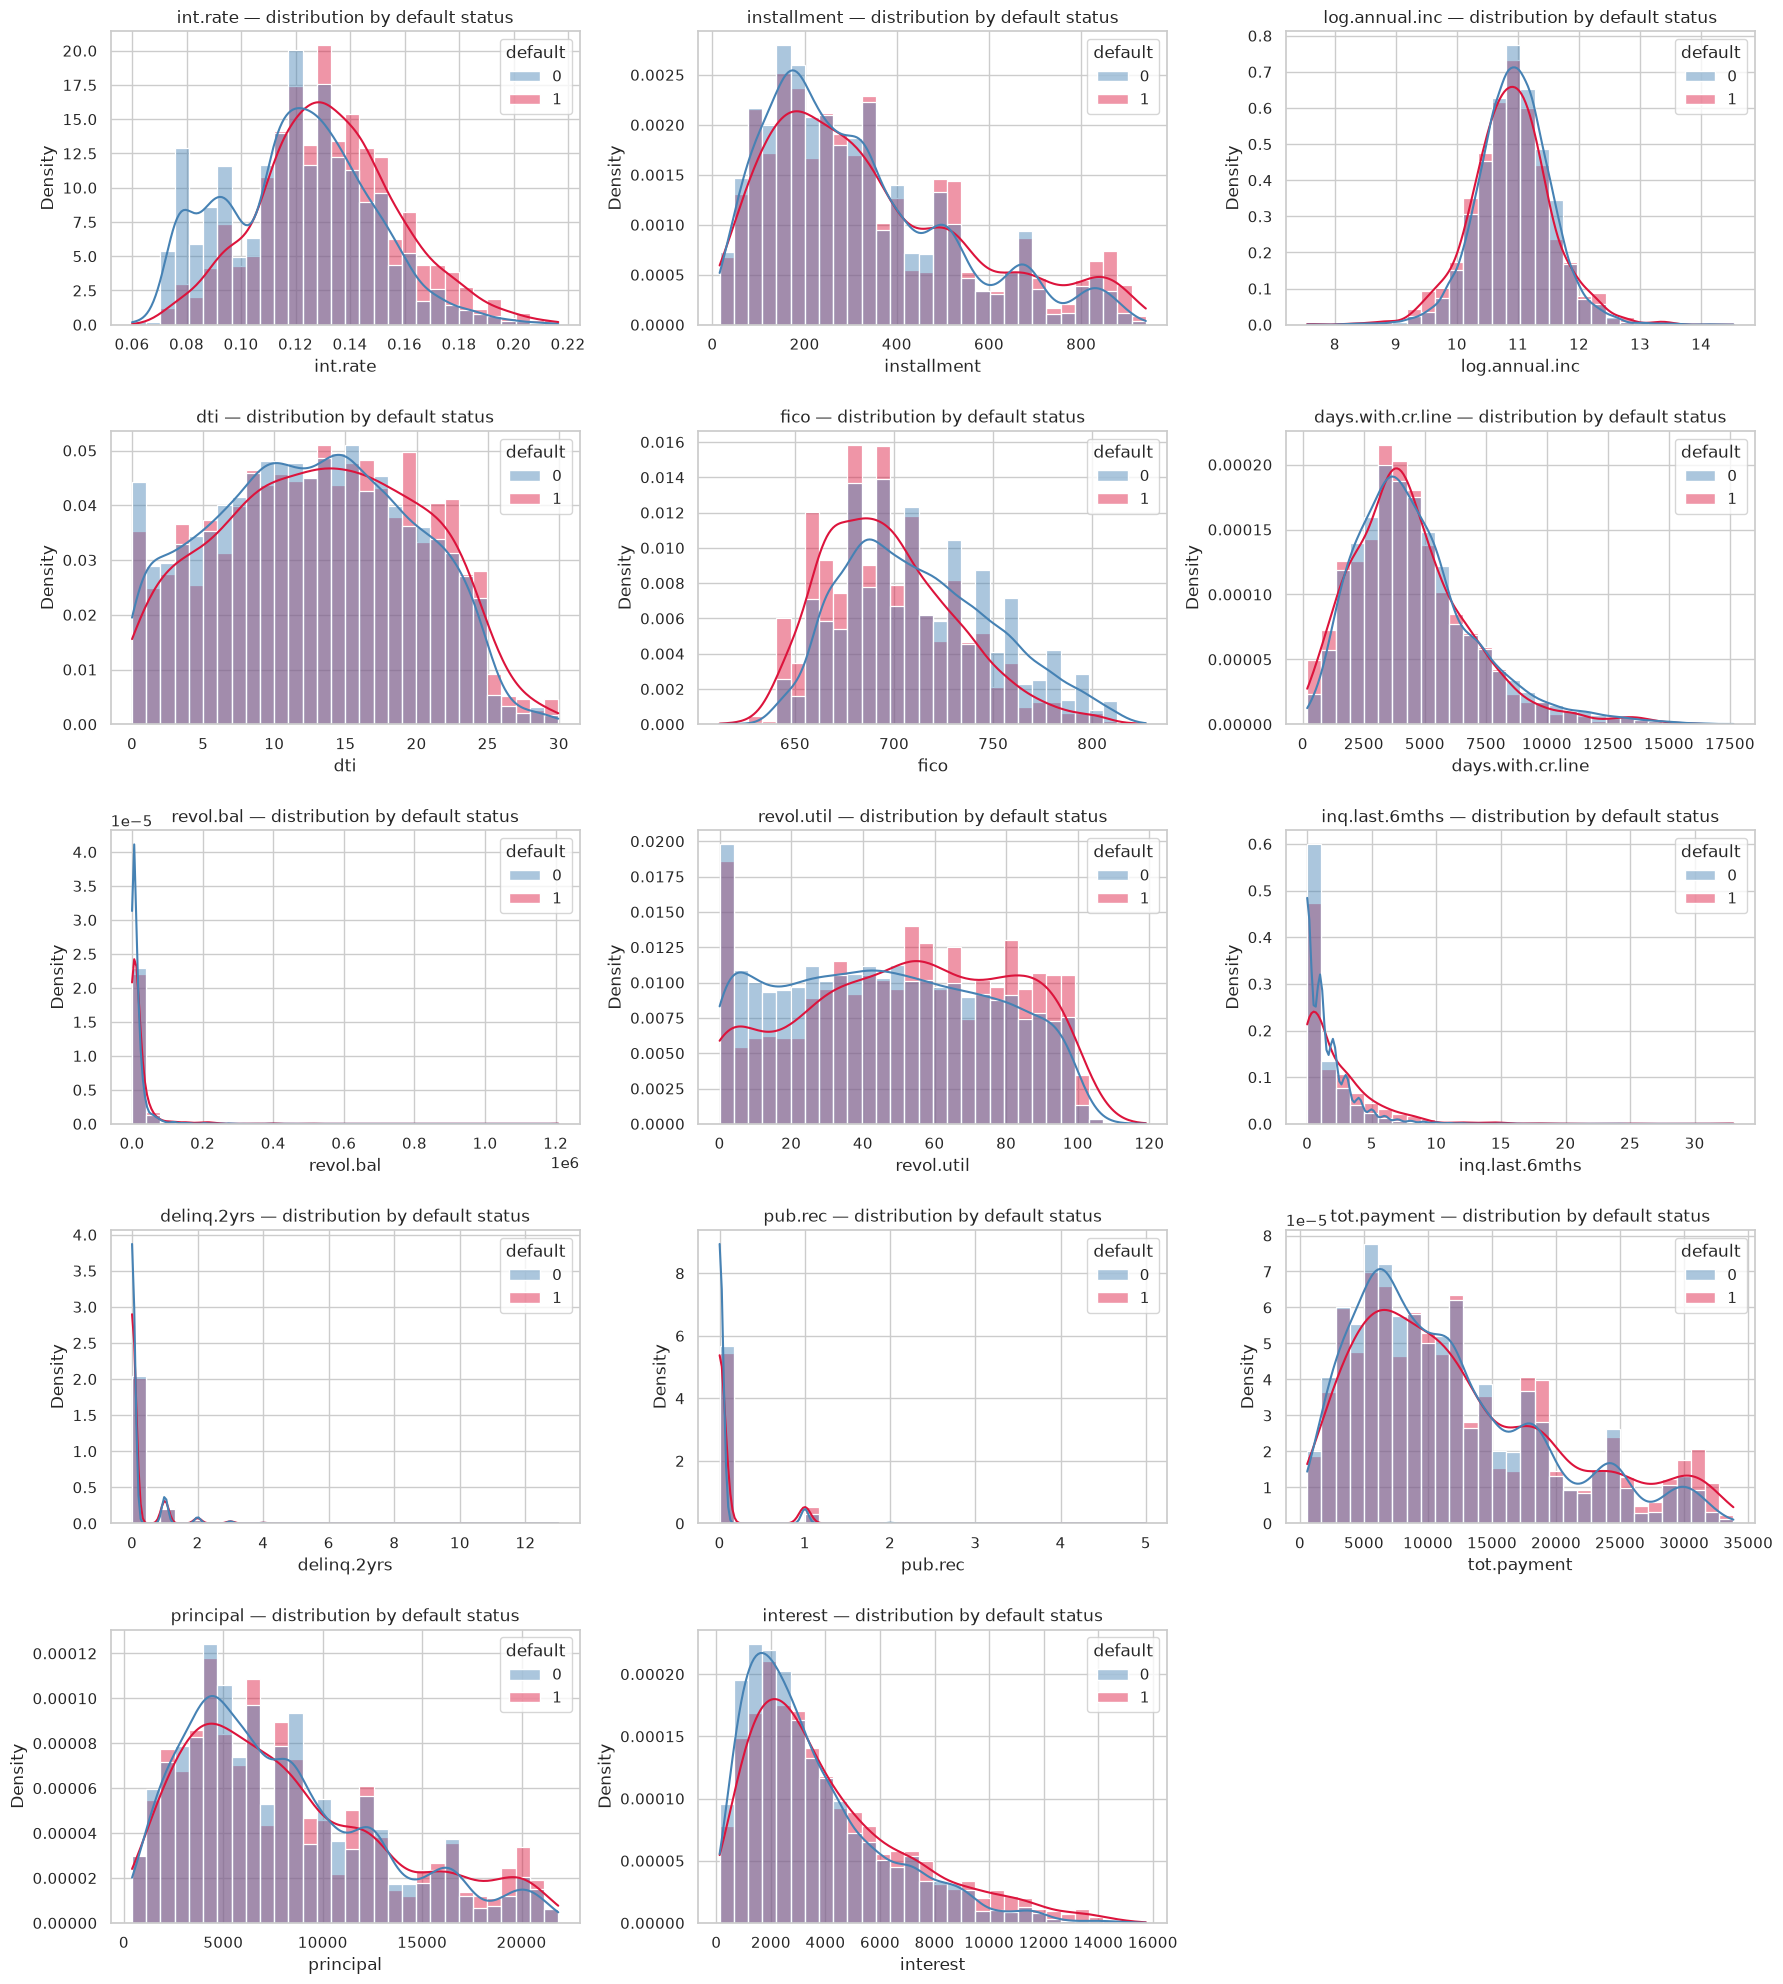

In [17]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='default', bins=30, kde=True,
                 stat='density', common_norm=False, palette=default_palette,
                 alpha=0.45, ax=axes[i])
    axes[i].set_title(f'{col} — distribution by default status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../output/numerical_distributions_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Normalized (100%) distributions — default rate per bucket

Raw counts are dominated by the ~84%/16% class imbalance, which makes it hard
to see *which buckets are riskiest*. The charts below normalize each bucket
to 100%, so the height of the red segment is directly the **default rate**
for that bucket (category, for categorical variables; quantile bin, for
numerical variables).


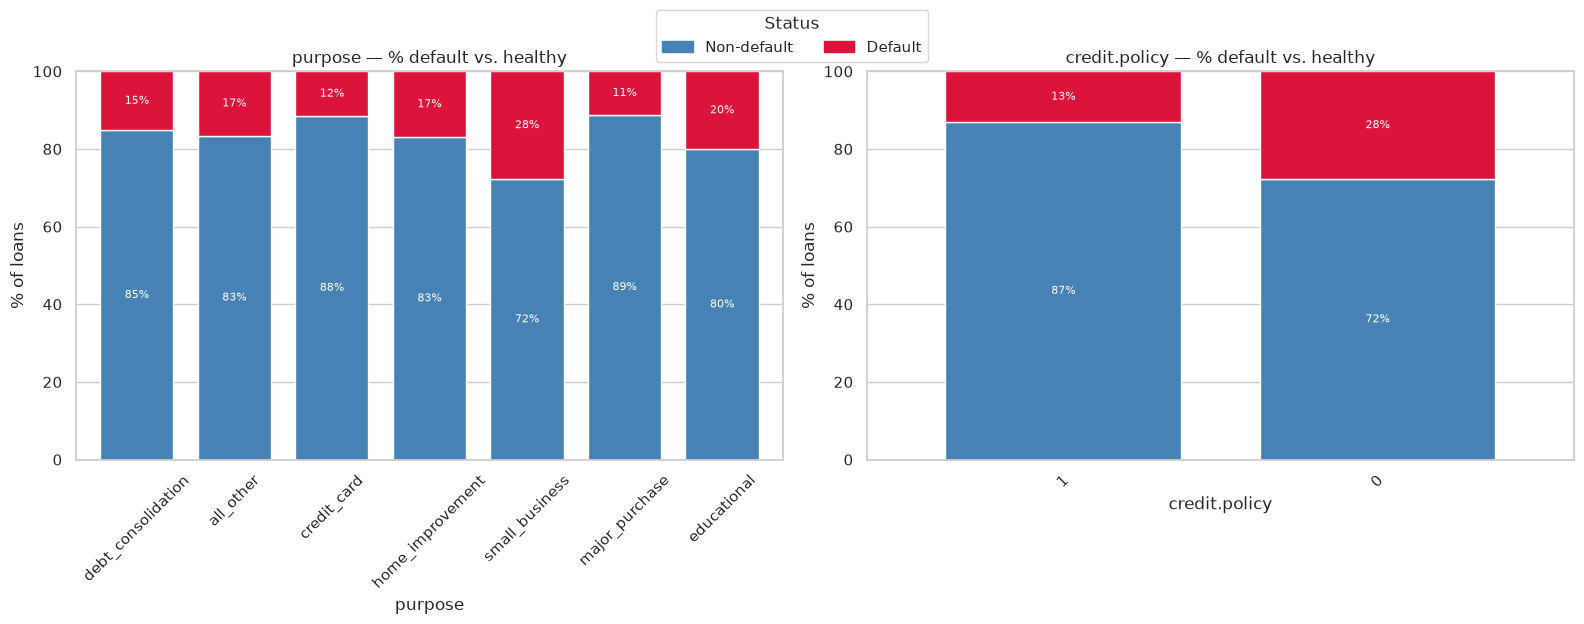

In [18]:
def plot_100pct_stacked(ax, series, default, title, xlabel, order=None):
    tab = pd.crosstab(series, default, normalize='index') * 100
    if order is not None:
        tab = tab.reindex(order)
    tab = tab.rename(columns=default_labels)
    tab[[default_labels[0], default_labels[1]]].plot(
        kind='bar', stacked=True, ax=ax,
        color=[default_palette[0], default_palette[1]], width=0.75, legend=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('% of loans')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        labels = [f'{v:.0f}%' if v >= 5 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='white')

fig, axes = plt.subplots(1, len(split_categorical_cols), figsize=(16, 6))
for ax, col in zip(axes, split_categorical_cols):
    order = df[col].value_counts().index
    plot_100pct_stacked(ax, df[col], df['default'], f'{col} — % default vs. healthy', col, order=order)
handles = [plt.Rectangle((0,0),1,1, color=default_palette[k]) for k in (0,1)]
fig.legend(handles, [default_labels[0], default_labels[1]], title='Status', loc='upper center',
           bbox_to_anchor=(0.5, 1.05), ncol=2)
plt.tight_layout()
plt.savefig('../output/categorical_normalized_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


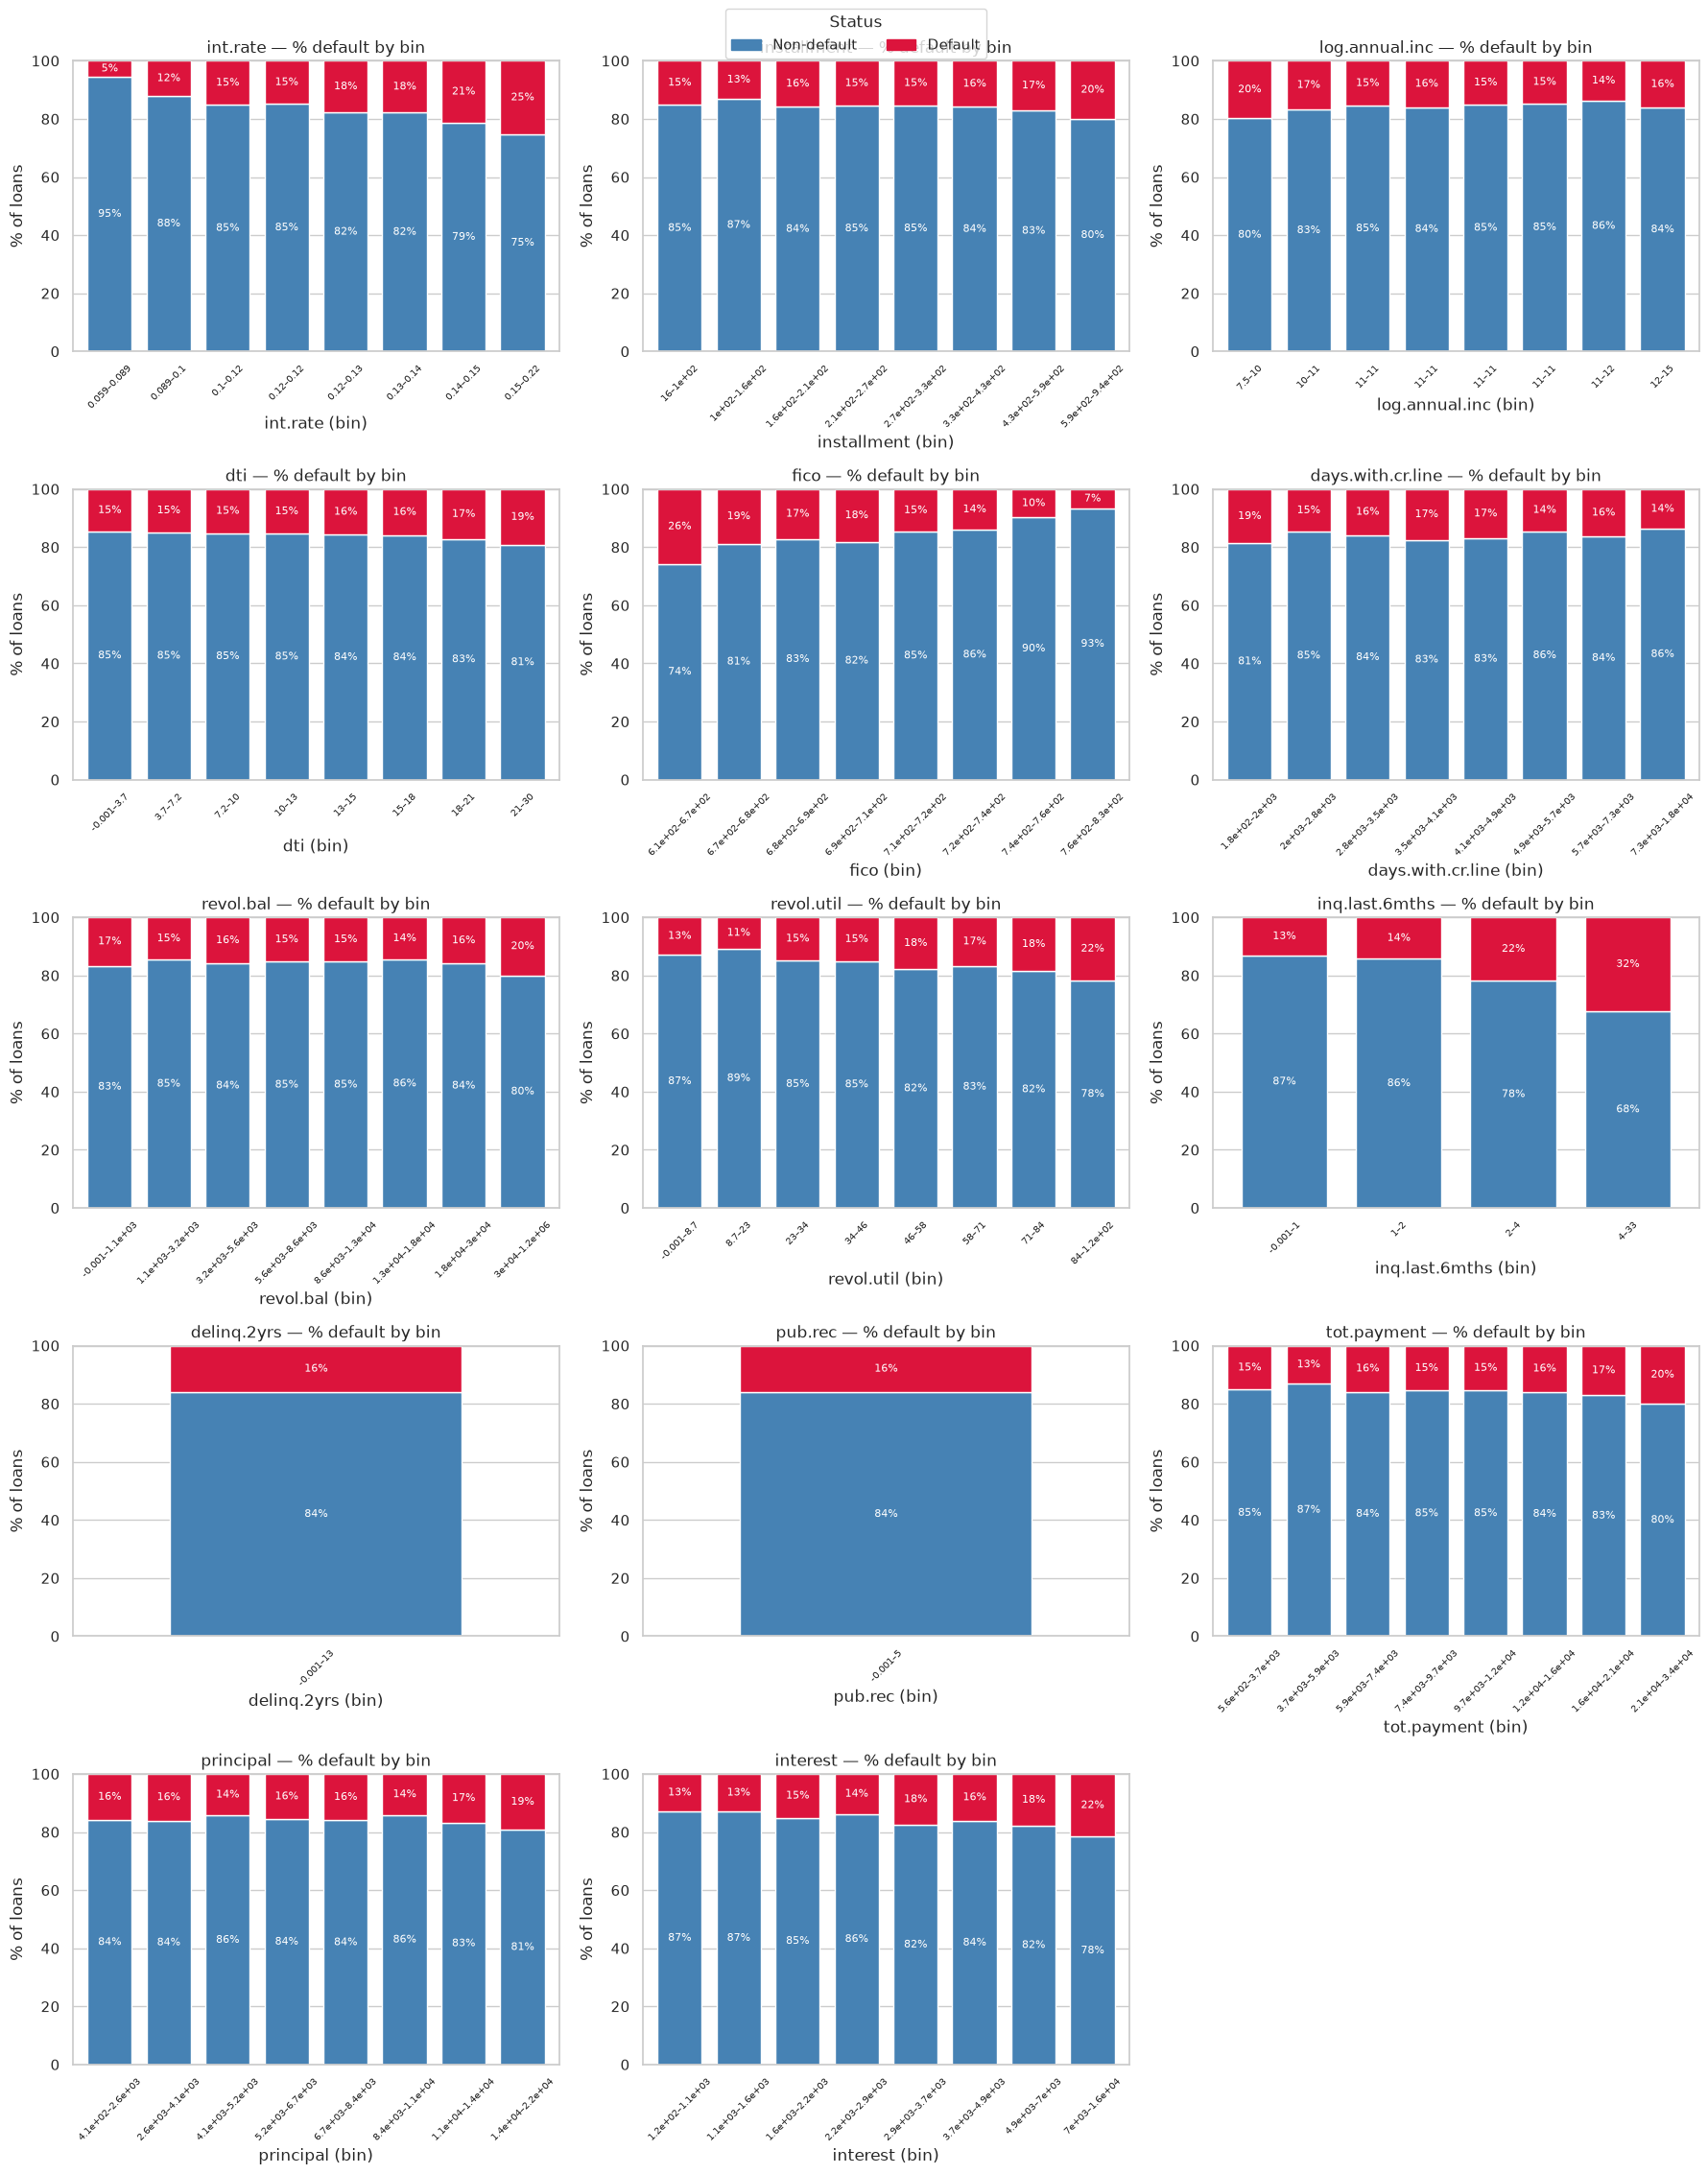

In [19]:
n_bins = 8
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    try:
        binned = pd.qcut(df[col], q=n_bins, duplicates='drop')
    except ValueError:
        binned = pd.cut(df[col], bins=n_bins)
    bin_order = binned.cat.categories
    plot_100pct_stacked(axes[i], binned, df['default'], f'{col} — % default by bin', f'{col} (bin)', order=bin_order)
    axes[i].set_xticklabels([f'{iv.left:.2g}–{iv.right:.2g}' for iv in bin_order], fontsize=7)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

handles = [plt.Rectangle((0,0),1,1, color=default_palette[k]) for k in (0,1)]
fig.legend(handles, [default_labels[0], default_labels[1]], title='Status', loc='upper center',
           bbox_to_anchor=(0.5, 1.01), ncol=2)
plt.tight_layout()
plt.savefig('../output/numerical_normalized_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Summary of findings

**Overall (Sections 1–8, PCA on funding-time predictors)**
- Class balance: 16.0% default (1,533/9,578); 80.5% of loans meet `credit.policy`.
- `int.rate` is set as a function of risk: it correlates negatively with `fico`
  and positively with `revol.util`. KPI fields (`tot.payment`, `principal`,
  `interest`) are near-deterministic functions of `installment`/`int.rate`
  and were excluded from PCA to avoid leakage.
- PCA on the 18 standardized predictor features (13 numeric + one-hot
  `purpose`) spreads variance fairly evenly — PC1 explains 15.3%, PC2 11.5%,
  PC3 8.9%, and ~13 components are needed for 90% cumulative variance.
  **PC1 is a risk/pricing axis** (high FICO, low `int.rate`/`revol.util`/`dti`,
  meets credit policy); default rate falls monotonically from 24.3% in the
  lowest PC1 quartile to 7.9% in the highest.

**New: distributions split by default status (Section 9) and normalized 100% views (Section 10)**

- **`purpose`**: default rates vary nearly 2.5x by stated purpose —
  `small_business` is by far the riskiest (27.8% default), followed by
  `educational` (20.1%), `home_improvement` (17.0%), `all_other` (16.6%), and
  `debt_consolidation` (15.2%); `credit_card` (11.6%) and `major_purchase`
  (11.2%) are the safest. This is a strong, cheap-to-use risk signal that PCA
  partially captures in PC3.
- **`credit.policy`**: loans that fail LendingClub's own underwriting
  criteria default at more than double the rate of those that pass (27.8% vs.
  13.2%). LendingClub's policy flag is doing real work, but it is far from a
  perfect filter — 13.2% of "approved" loans still default.
- **`fico`**: the cleanest, most monotonic risk gradient in the data —
  default rate falls from 25.8% in the lowest FICO bucket (612–667) to 6.6%
  in the top bucket (757–827), a ~4x spread. The by-default histogram
  (Section 9) shows the defaulted-loan distribution visibly shifted left
  (lower FICO) versus non-defaulted loans.
- **`int.rate`**: mirrors FICO as expected (since LendingClub prices risk
  into the rate) — default climbs from 5.4% in the lowest-rate octile to
  25.3% in the highest, a ~4.7x spread. `int.rate` and `fico` carry
  overlapping information (both load heavily on PC1).
- **`revol.util`** (credit utilization): a clear, mostly monotonic gradient
  from ~11–13% default at low utilization up to 21.6% for borrowers using
  >84.5% of their revolving credit — a classic over-leveraged-borrower signal.
- **`inq.last.6mths`** (recent credit inquiries): the sharpest gradient of
  all — default rate roughly triples from 13.1% (0–1 inquiries) to 32.3%
  (5+ inquiries in the last 6 months). Recent credit-shopping behavior is one
  of the strongest individual risk markers in this data set.
- **`dti`, `log.annual.inc`, `revol.bal`, `days.with.cr.line`, `installment`,
  `principal`/`interest`/`tot.payment`**: mostly flat in the middle bins with
  a mild uptick only in the extreme (highest-risk) octile — e.g. `dti` rises
  from ~14.6% to 19.3% and `revol.bal` jumps to 19.9% only in its top octile
  (large, right-skewed balances). These variables matter mainly for
  identifying tail risk rather than as smooth linear predictors.
- **`delinq.2yrs` and `pub.rec`**: too concentrated at 0 (most borrowers have
  zero delinquencies/public records) to form meaningful quantile bins — the
  normalized chart for these effectively collapses to a single bucket. Any
  future work should treat these as sparse/count-like flags (e.g.
  `delinq.2yrs > 0`) rather than continuous variables.

**Practical takeaway**: the 100%-normalized views make it clear that no
single variable perfectly separates defaults from healthy loans (every
bucket still contains a majority of non-defaults), but `fico`, `int.rate`,
`inq.last.6mths`, `revol.util`, `purpose`, and `credit.policy` all show real,
often near-monotonic gradients in default rate. These are the strongest
candidate features for the logistic regression screening model referenced in
the case (Update 2), while `delinq.2yrs`/`pub.rec` likely need to be
re-encoded as binary/count flags rather than used as continuous predictors.
